Number of UCCSD parameters: 3
     ┌───┐┌───────────────────────────────┐┌───────────────────────────────┐»
q_0: ┤ X ├┤0                              ├┤0                              ├»
     └───┘│                               ││                               │»
q_1: ─────┤1                              ├┤1                              ├»
     ┌───┐│  exp(-it (IIXY + IIYX))(t[0]) ││  exp(-it (XYII + YXII))(t[1]) │»
q_2: ┤ X ├┤2                              ├┤2                              ├»
     └───┘│                               ││                               │»
q_3: ─────┤3                              ├┤3                              ├»
          └───────────────────────────────┘└───────────────────────────────┘»
«     ┌─────────────────────────────────────────────────────────────────────────┐
«q_0: ┤0                                                                        ├
«     │                                                                         │
«q_1: ┤1              

/home/bharath/VQE/.venv/lib/python3.13/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/home/bharath/VQE/.venv/lib/python3.13/site-packages/scipy/sparse/linalg/_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)


R = 0.20 Å | Exact = 0.157482 | VQE = 0.157482
R = 0.30 Å | Exact = -0.601804 | VQE = -0.601804
R = 0.40 Å | Exact = -0.914150 | VQE = -0.914150
R = 0.50 Å | Exact = -1.055160 | VQE = -1.055160
R = 0.60 Å | Exact = -1.116286 | VQE = -1.116286
R = 0.70 Å | Exact = -1.136189 | VQE = -1.136189
R = 0.80 Å | Exact = -1.134148 | VQE = -1.134148
R = 0.90 Å | Exact = -1.120560 | VQE = -1.120560
R = 1.00 Å | Exact = -1.101150 | VQE = -1.101150
R = 1.10 Å | Exact = -1.079193 | VQE = -1.079193
R = 1.20 Å | Exact = -1.056741 | VQE = -1.056741
R = 1.30 Å | Exact = -1.035186 | VQE = -1.035186
R = 1.40 Å | Exact = -1.015468 | VQE = -1.015468
R = 1.50 Å | Exact = -0.998149 | VQE = -0.998149
R = 1.60 Å | Exact = -0.983473 | VQE = -0.983473
R = 1.70 Å | Exact = -0.971427 | VQE = -0.971427
R = 1.80 Å | Exact = -0.961817 | VQE = -0.961817
R = 1.90 Å | Exact = -0.954339 | VQE = -0.954339
R = 2.00 Å | Exact = -0.948641 | VQE = -0.948641
R = 2.10 Å | Exact = -0.944375 | VQE = -0.944375
R = 2.20 Å | Exact = -

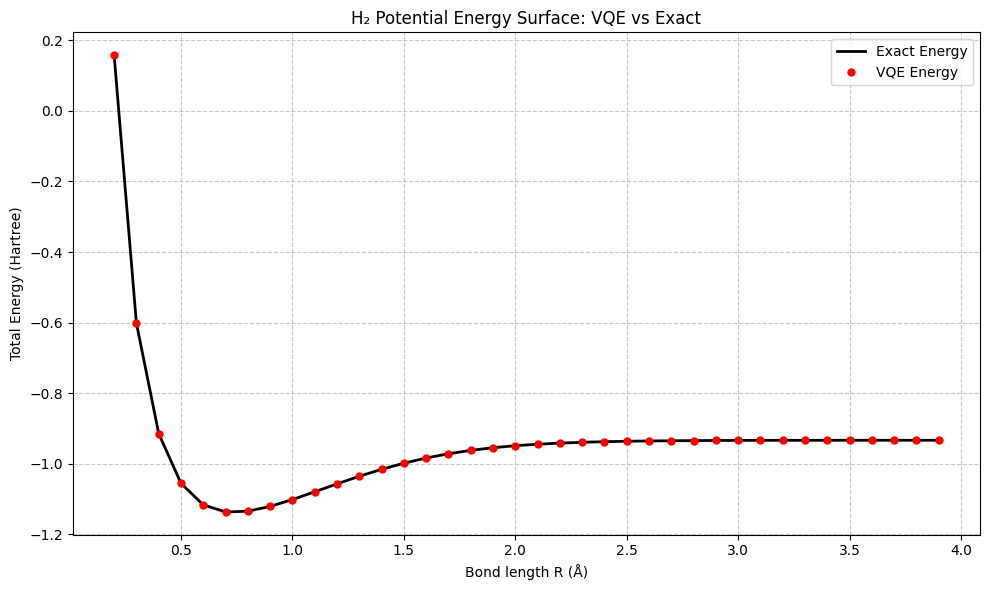

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import qiskit_nature
from qiskit_algorithms import NumPyMinimumEigensolver, VQE
from qiskit_algorithms.optimizers import SLSQP
from qiskit_nature.second_q.formats.molecule_info import MoleculeInfo
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.circuit.library import UCCSD, HartreeFock
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit.primitives import StatevectorEstimator

qiskit_nature.settings.use_pauli_sum_op = False


def get_qubit_op(dist):
    molecule = MoleculeInfo(
        symbols=["H", "H"],
        coords=([0.0, 0.0, 0.0], [dist, 0.0, 0.0]),
        multiplicity=1,
        charge=0,
    )

    driver = PySCFDriver.from_molecule(molecule, basis="sto3g")
    problem = driver.run()

    num_particles = problem.num_particles
    num_spatial_orbitals = problem.num_spatial_orbitals

    mapper = JordanWignerMapper()
    qubit_op = mapper.map(problem.second_q_ops()[0])

    return qubit_op, num_particles, num_spatial_orbitals, problem, mapper


def exact_solver(qubit_op, problem):
    sol = NumPyMinimumEigensolver().compute_minimum_eigenvalue(qubit_op)
    return problem.interpret(sol)


# Test ansatz at equilibrium bond length
qubit_op, num_particles, num_spatial_orbitals, problem, mapper = get_qubit_op(0.74)

init_state = HartreeFock(
    num_spatial_orbitals,
    num_particles,
    mapper
)

uccsd_ansatz = UCCSD(
    num_spatial_orbitals,
    num_particles,
    mapper,
    initial_state=init_state
)

print("Number of UCCSD parameters:", uccsd_ansatz.num_parameters)
print(uccsd_ansatz.decompose().draw())


# Bond lengths
distances = np.arange(0.2, 4.0, 0.1)

exact_energies = []
vqe_energies = []

optimizer = SLSQP(maxiter=100)
estimator = StatevectorEstimator()

print("Calculating energies for H2...")

for dist in distances:
    qubit_op, num_particles, num_spatial_orbitals, problem, mapper = get_qubit_op(dist)

    exact_result = exact_solver(qubit_op, problem)
    exact_energy = exact_result.total_energies[0].real
    exact_energies.append(exact_energy)

    init_state = HartreeFock(
        num_spatial_orbitals,
        num_particles,
        mapper
    )

    ansatz = UCCSD(
        num_spatial_orbitals,
        num_particles,
        mapper,
        initial_state=init_state
    )

    vqe = VQE(
        estimator,
        ansatz,
        optimizer,
        initial_point=[0.0] * ansatz.num_parameters
    )

    vqe_calc = vqe.compute_minimum_eigenvalue(qubit_op)
    vqe_energy = problem.interpret(vqe_calc).total_energies[0].real
    vqe_energies.append(vqe_energy)

    print(
        f"R = {dist:.2f} Å | "
        f"Exact = {exact_energy:.6f} | "
        f"VQE = {vqe_energy:.6f}"
    )

print("All energies calculated.")


plt.figure(figsize=(10, 6))

plt.plot(
    distances,
    exact_energies,
    label="Exact Energy",
    color="black",
    linewidth=2
)

plt.plot(
    distances,
    vqe_energies,
    label="VQE Energy",
    marker="o",
    markersize=5,
    linestyle="none",
    color="red"
)

plt.xlabel("Bond length R (Å)")
plt.ylabel("Total Energy (Hartree)")
plt.title("H₂ Potential Energy Surface: VQE vs Exact")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()